## **Imports & Setup**

In [1]:
import os
import torch
import torch.nn as nn
from torchvision import transforms
from torchvision.models import efficientnet_b4, EfficientNet_B4_Weights
import pickle

BASE_DIR = os.path.abspath(os.path.join(os.getcwd(), ".."))
MODELS_DIR = os.path.join(BASE_DIR, "models")
RESULTS_DIR = os.path.join(BASE_DIR, "results")

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Environment Initialized on {device}.")

Environment Initialized on cuda.


## **1.EfficientNetB4**

### **Architecture Definition**

In [2]:
class EfficientNetB4Classifier(nn.Module):
    def __init__(self, num_classes=1, freeze_backbone=True):
        super(EfficientNetB4Classifier, self).__init__()
        
        # Load pretrained EfficientNetB4
        self.backbone = efficientnet_b4(weights=EfficientNet_B4_Weights.IMAGENET1K_V1)
        
        # Freeze backbone weights
        if freeze_backbone:
            for param in self.backbone.parameters():
                param.requires_grad = False
                
        # Replace the classifier head
        num_features = self.backbone.classifier[1].in_features
        self.backbone.classifier = nn.Sequential(
            nn.Dropout(p=0.4),
            nn.Linear(num_features, 512),
            nn.ReLU(),
            nn.BatchNorm1d(512),
            nn.Dropout(p=0.3),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.BatchNorm1d(256),
            nn.Dropout(p=0.3),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        return self.backbone(x)

efficientnet_model = EfficientNetB4Classifier().to(device)
print("EfficientNetB4 Architecture Initialized.")

EfficientNetB4 Architecture Initialized.


### **Initialize Dataloaders for Pretrained Models**

In [20]:
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import pickle

# 1. Load the dataset info (Batch size, etc.)
info_path = os.path.join(RESULTS_DIR, 'dataset_info.pkl')
with open(info_path, 'rb') as f:
    dataset_info = pickle.load(f)

BATCH_SIZE = dataset_info['batch_size']
INPUT_SIZE = 224 # Forcing 224x224 for pretrained models

print(f"Configuring DataLoaders - Input Size: {INPUT_SIZE}x{INPUT_SIZE}, Batch Size: {BATCH_SIZE}")

# 2. Define Transforms (Augmentation for Train, Standard for Val)
train_transform = transforms.Compose([
    transforms.Resize((INPUT_SIZE, INPUT_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((INPUT_SIZE, INPUT_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# 3. Dataset Class
class DeepfakeDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.images = []
        self.labels = []
        self.class_to_label = {'fake': 0, 'real': 1}
        
        for class_name, label in self.class_to_label.items():
            class_path = os.path.join(root_dir, class_name)
            if os.path.exists(class_path):
                for img_file in os.listdir(class_path):
                    if img_file.lower().endswith(('.jpg', '.jpeg', '.png')):
                        self.images.append(os.path.join(class_path, img_file))
                        self.labels.append(label)

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_path = self.images[idx]
        label = self.labels[idx]
        try:
            image = Image.open(img_path).convert('RGB')
        except Exception:
            return self.__getitem__((idx + 1) % len(self.images))
        if self.transform:
            image = self.transform(image)
        return image, label

# 4. Initialize DataLoaders
DATASET_PATH = os.path.join(BASE_DIR, "Dataset")

train_dataset = DeepfakeDataset(os.path.join(DATASET_PATH, 'train'), transform=train_transform)
val_dataset = DeepfakeDataset(os.path.join(DATASET_PATH, 'validation'), transform=val_transform)

# IMPORTANT: Added pin_memory=True to speed up GPU transfer
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, pin_memory=True)

# Initialize Test DataLoader (uses the same transform as validation)
test_dataset = DeepfakeDataset(os.path.join(DATASET_PATH, 'test'), transform=val_transform)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, pin_memory=True)

print(f"DataLoaders Ready. Train batches: {len(train_loader)} | Val batches: {len(val_loader)}")

Configuring DataLoaders - Input Size: 224x224, Batch Size: 64
DataLoaders Ready. Train batches: 2188 | Val batches: 617


### **Training Setup**

In [15]:
import os
import torch
import torch.optim as optim
import torch.nn as nn
from tqdm import tqdm
import warnings

# Suppress annoying warnings
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', module='tqdm')
# Trainer class strictly configured for the Custom CNN architecture
class Trainer:
    def __init__(self, model, model_name, device, learning_rate=0.001):
        self.model = model.to(device)
        self.model_name = model_name
        self.device = device
        
        # BCEWithLogitsLoss provides numeric stability for binary classification
        self.criterion = nn.BCEWithLogitsLoss()
        self.optimizer = optim.Adam(self.model.parameters(), lr=learning_rate, weight_decay=1e-4)
        
        # Reduce learning rate when validation loss stops improving
        self.scheduler = optim.lr_scheduler.ReduceLROnPlateau(
            self.optimizer, mode='min', patience=3, factor=0.5
        )
        
        self.history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
        self.best_val_acc = 0
        self.start_epoch = 0

    # Save full training state for potential resuming
    def save_checkpoint(self, filepath, epoch):
        checkpoint = {
            'epoch': epoch,
            'model_state_dict': self.model.state_dict(),
            'optimizer_state_dict': self.optimizer.state_dict(),
            'scheduler_state_dict': self.scheduler.state_dict(),
            'best_val_acc': self.best_val_acc,
            'history': self.history
        }
        torch.save(checkpoint, filepath)

    # Load previous training state
    def load_checkpoint(self, filepath):
        checkpoint = torch.load(filepath, map_location=self.device)
        self.model.load_state_dict(checkpoint['model_state_dict'])
        self.optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
        self.scheduler.load_state_dict(checkpoint['scheduler_state_dict'])
        self.start_epoch = checkpoint['epoch'] + 1
        self.best_val_acc = checkpoint['best_val_acc']
        self.history = checkpoint['history']

    # Execute a single training epoch
    def train_epoch(self, loader):
        self.model.train()
        running_loss = 0.0
        correct = 0
        total = 0
        
        for images, labels in tqdm(loader, desc=f"Training {self.model_name}"):
            images, labels = images.to(self.device), labels.to(self.device)
            labels = labels.float().unsqueeze(1)
            
            self.optimizer.zero_grad()
            outputs = self.model(images)
            loss = self.criterion(outputs, labels)
            loss.backward()
            self.optimizer.step()
            
            running_loss += loss.item()
            predicted = (torch.sigmoid(outputs) > 0.5).float()
            correct += (predicted == labels).sum().item()
            total += labels.size(0)
            
        return running_loss / len(loader), 100. * correct / total

    # Execute a single validation epoch
    def validate_epoch(self, loader):
        self.model.eval()
        running_loss = 0.0
        correct = 0
        total = 0
        
        with torch.no_grad():
            for images, labels in tqdm(loader, desc=f"Validating {self.model_name}"):
                images, labels = images.to(self.device), labels.to(self.device)
                labels = labels.float().unsqueeze(1)
                
                outputs = self.model(images)
                loss = self.criterion(outputs, labels)
                
                running_loss += loss.item()
                predicted = (torch.sigmoid(outputs) > 0.5).float()
                correct += (predicted == labels).sum().item()
                total += labels.size(0)
                
        return running_loss / len(loader), 100. * correct / total

    # Main training loop execution
    def train(self, train_loader, val_loader, epochs, save_path=None, resume_path=None, save_every=1):
        if resume_path and os.path.exists(resume_path):
            self.load_checkpoint(resume_path)
            print(f"Resuming {self.model_name} from epoch {self.start_epoch}")
            
        for epoch in range(self.start_epoch, epochs):
            print(f"\nEpoch {epoch+1}/{epochs}:")
            
            train_loss, train_acc = self.train_epoch(train_loader)
            val_loss, val_acc = self.validate_epoch(val_loader)
            
            self.history['train_loss'].append(train_loss)
            self.history['train_acc'].append(train_acc)
            self.history['val_loss'].append(val_loss)
            self.history['val_acc'].append(val_acc)
            
            self.scheduler.step(val_loss)
            current_lr = self.optimizer.param_groups[0]['lr']
            
            print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}%")
            print(f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}%")
            print(f"Learning Rate: {current_lr:.6f}")
            
            if val_acc > self.best_val_acc and save_path:
                self.best_val_acc = val_acc
                # Save the best model state with history for full restoration
                torch.save({
                    'model_state_dict': self.model.state_dict(),
                    'val_acc': val_acc,
                    'epoch': epoch,
                    'history': self.history
                }, save_path)
                print(f"Saved new best model with accuracy: {val_acc:.2f}%")
                
            if resume_path and (epoch + 1) % save_every == 0:
                self.save_checkpoint(resume_path, epoch)
                
        print(f"\nTraining Complete. Best Validation Accuracy: {self.best_val_acc:.2f}%")
        return self.history

print("Trainer Class Initialized.")

Trainer Class Initialized.


### **Execution**

In [8]:
best_weights_path = os.path.join(MODELS_DIR, 'efficientnet_best.pth')
checkpoint_path = os.path.join(MODELS_DIR, 'efficientnet_checkpoint.pth')

efficientnet_trainer = Trainer(
    model=efficientnet_model,
    model_name="EfficientNetB4",
    device=device,
    learning_rate=0.001
)

try:
    efficientnet_history = efficientnet_trainer.train(
        train_loader=train_loader,
        val_loader=val_loader,
        epochs=5,
        save_path=best_weights_path,
        resume_path=checkpoint_path,
        save_every=1
    )
    
    with open(os.path.join(RESULTS_DIR, 'efficientnet_history.pkl'), 'wb') as f:
        pickle.dump(efficientnet_history, f)
        
except KeyboardInterrupt:
    print("Training interrupted manually.")


Epoch 1/5:


Validating EfficientNetB4: 100%|█████████████████████████████████████████████████████| 617/617 [03:27<00:00,  2.98it/s]


Train Loss: 0.4718 | Train Acc: 77.11%
Val Loss: 0.4430 | Val Acc: 78.98%
Learning Rate: 0.001000
Saved new best model with accuracy: 78.98%

Epoch 2/5:


Validating EfficientNetB4: 100%|█████████████████████████████████████████████████████| 617/617 [03:09<00:00,  3.26it/s]


Train Loss: 0.4517 | Train Acc: 78.39%
Val Loss: 0.4434 | Val Acc: 78.95%
Learning Rate: 0.001000

Epoch 3/5:


...

Train Loss: 0.4451 | Train Acc: 78.81%
Val Loss: 0.4355 | Val Acc: 79.63%
Learning Rate: 0.001000
Saved new best model with accuracy: 79.63%

Epoch 4/5:


Validating EfficientNetB4: 100%|█████████████████████████████████████████████████████| 617/617 [03:46<00:00,  2.72it/s]


Train Loss: 0.4410 | Train Acc: 79.05%
Val Loss: 0.4319 | Val Acc: 79.62%
Learning Rate: 0.001000

Epoch 5/5:


Validating EfficientNetB4: 100%|█████████████████████████████████████████████████████| 617/617 [04:04<00:00,  2.53it/s]


Train Loss: 0.4403 | Train Acc: 78.96%
Val Loss: 0.4362 | Val Acc: 79.72%
Learning Rate: 0.001000
Saved new best model with accuracy: 79.72%

Training Complete. Best Validation Accuracy: 79.72%


### **Evaluation**

Evaluating EfficientNetB4 on the Test Set...

=== TEST SET RESULTS ===
Accuracy : 74.04%
Precision: 74.56%
Recall   : 72.40%
F1 Score : 73.47%

Classification Report:
              precision    recall  f1-score   support

        Fake       0.74      0.76      0.75      5492
        Real       0.75      0.72      0.73      5413

    accuracy                           0.74     10905
   macro avg       0.74      0.74      0.74     10905
weighted avg       0.74      0.74      0.74     10905



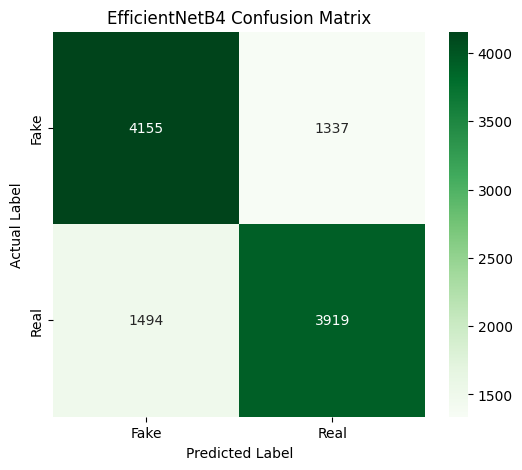

Results successfully saved to efficientnet_results.json


In [22]:
import json
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

print("Evaluating EfficientNetB4 on the Test Set...")

# Ensure model is using the best saved weights
checkpoint = torch.load(best_weights_path, map_location=device, weights_only=False)
efficientnet_model.load_state_dict(checkpoint['model_state_dict'])
efficientnet_model.eval()

all_preds = []
all_labels = []

# Run inference without gradient tracking
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = efficientnet_model(images)
        probs = torch.sigmoid(outputs).cpu().numpy().flatten()
        preds = (probs > 0.5).astype(int)
        
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

# Calculate final metrics
accuracy = accuracy_score(all_labels, all_preds) * 100
precision = precision_score(all_labels, all_preds) * 100
recall = recall_score(all_labels, all_preds) * 100
f1 = f1_score(all_labels, all_preds) * 100

print("\n=== TEST SET RESULTS ===")
print(f"Accuracy : {accuracy:.2f}%")
print(f"Precision: {precision:.2f}%")
print(f"Recall   : {recall:.2f}%")
print(f"F1 Score : {f1:.2f}%")
print("\nClassification Report:")
print(classification_report(all_labels, all_preds, target_names=['Fake', 'Real']))

# Plot and save Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(6, 5))
# Using 'Greens' colormap to visually distinguish it from XceptionNet's Oranges and the Custom CNN's Blues
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', xticklabels=['Fake', 'Real'], yticklabels=['Fake', 'Real'])
plt.title('EfficientNetB4 Confusion Matrix')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.savefig(os.path.join(RESULTS_DIR, 'efficientnet_confusion_matrix.png'), dpi=150, bbox_inches='tight')
plt.show()

# Save metrics to JSON
results = {
    'model_name': 'EfficientNetB4',
    'test_accuracy': round(accuracy, 2),
    'test_precision': round(precision, 2),
    'test_recall': round(recall, 2),
    'test_f1': round(f1, 2)
}
with open(os.path.join(RESULTS_DIR, 'efficientnet_results.json'), 'w') as f:
    json.dump(results, f, indent=4)
print("Results successfully saved to efficientnet_results.json")

## **Export to Standalone TorchScript**

In [23]:
# Load the best weights securely
checkpoint = torch.load(best_weights_path, map_location=device, weights_only=True)
efficientnet_model.load_state_dict(checkpoint['model_state_dict'])

# Convert to TorchScript
efficientnet_model.eval()
dummy_input = torch.randn(1, 3, 224, 224).to(device)
scripted_model = torch.jit.trace(efficientnet_model, dummy_input)

# Save standalone model
standalone_path = os.path.join(MODELS_DIR, 'efficientnet_standalone.pt')
scripted_model.save(standalone_path)
print(f"Standalone TorchScript model saved at: {standalone_path}")

Standalone TorchScript model saved at: C:\Users\javed\Home\Deepfake-Detection\models\efficientnet_standalone.pt


## **2. XceptionNet**

### **Architecture Definition**

In [16]:
import timm

class XceptionClassifier(nn.Module):
    def __init__(self, num_classes=1, freeze_backbone=True):
        super(XceptionClassifier, self).__init__()
        
        # Load pretrained Xception via timm (num_classes=0 removes its default head)
        self.backbone = timm.create_model('legacy_xception', pretrained=True, num_classes=0)
        
        # Freeze backbone weights
        if freeze_backbone:
            for param in self.backbone.parameters():
                param.requires_grad = False
                
        num_features = self.backbone.num_features
        
        # Custom classifier head
        self.classifier = nn.Sequential(
            nn.Dropout(p=0.4),
            nn.Linear(num_features, 512),
            nn.ReLU(),
            nn.BatchNorm1d(512),
            nn.Dropout(p=0.3),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.BatchNorm1d(256),
            nn.Dropout(p=0.3),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.backbone(x)
        return self.classifier(x)

xception_model = XceptionClassifier().to(device)
print("XceptionNet Architecture Initialized.")

XceptionNet Architecture Initialized.


### **Training Execution**

In [17]:
best_weights_path_xc = os.path.join(MODELS_DIR, 'xception_best.pth')
checkpoint_path_xc = os.path.join(MODELS_DIR, 'xception_checkpoint.pth')

xception_trainer = Trainer(
    model=xception_model,
    model_name="XceptionNet",
    device=device,
    learning_rate=0.001
)

try:
    xception_history = xception_trainer.train(
        train_loader=train_loader,
        val_loader=val_loader,
        epochs=5,
        save_path=best_weights_path_xc,
        resume_path=checkpoint_path_xc,
        save_every=1
    )
    
    with open(os.path.join(RESULTS_DIR, 'xception_history.pkl'), 'wb') as f:
        pickle.dump(xception_history, f)
        
except KeyboardInterrupt:
    print("Training interrupted manually.")

Resuming XceptionNet from epoch 5

Training Complete. Best Validation Accuracy: 79.79%


### **Evaluation**

Evaluating XceptionNet on the Test Set...

=== TEST SET RESULTS ===
Accuracy : 70.38%
Precision: 75.19%
Recall   : 60.19%
F1 Score : 66.86%

Classification Report:
              precision    recall  f1-score   support

        Fake       0.67      0.80      0.73      5492
        Real       0.75      0.60      0.67      5413

    accuracy                           0.70     10905
   macro avg       0.71      0.70      0.70     10905
weighted avg       0.71      0.70      0.70     10905



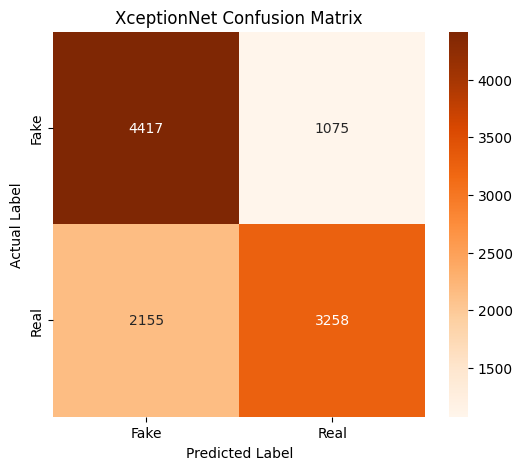

Results successfully saved to xception_results.json


In [21]:
import json
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

print("Evaluating XceptionNet on the Test Set...")

# Ensure model is using the best saved weights
checkpoint = torch.load(best_weights_path_xc, map_location=device, weights_only=True)
xception_model.load_state_dict(checkpoint['model_state_dict'])
xception_model.eval()

all_preds = []
all_labels = []

# Run inference without gradient tracking
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = xception_model(images)
        probs = torch.sigmoid(outputs).cpu().numpy().flatten()
        preds = (probs > 0.5).astype(int)
        
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

# Calculate final metrics
accuracy = accuracy_score(all_labels, all_preds) * 100
precision = precision_score(all_labels, all_preds) * 100
recall = recall_score(all_labels, all_preds) * 100
f1 = f1_score(all_labels, all_preds) * 100

print("\n=== TEST SET RESULTS ===")
print(f"Accuracy : {accuracy:.2f}%")
print(f"Precision: {precision:.2f}%")
print(f"Recall   : {recall:.2f}%")
print(f"F1 Score : {f1:.2f}%")
print("\nClassification Report:")
print(classification_report(all_labels, all_preds, target_names=['Fake', 'Real']))

# Plot and save Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges', xticklabels=['Fake', 'Real'], yticklabels=['Fake', 'Real'])
plt.title('XceptionNet Confusion Matrix')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.savefig(os.path.join(RESULTS_DIR, 'xception_confusion_matrix.png'), dpi=150, bbox_inches='tight')
plt.show()

# Save metrics to JSON
results = {
    'model_name': 'XceptionNet',
    'test_accuracy': round(accuracy, 2),
    'test_precision': round(precision, 2),
    'test_recall': round(recall, 2),
    'test_f1': round(f1, 2)
}
with open(os.path.join(RESULTS_DIR, 'xception_results.json'), 'w') as f:
    json.dump(results, f, indent=4)
print("Results successfully saved to xception_results.json")

### **TorchScript Export**

In [24]:
# Convert to TorchScript
xception_model.eval()
dummy_input = torch.randn(1, 3, 224, 224).to(device)
scripted_model_xc = torch.jit.trace(xception_model, dummy_input)

# Save standalone model
standalone_path_xc = os.path.join(MODELS_DIR, 'xception_standalone.pt')
scripted_model_xc.save(standalone_path_xc)
print(f"Standalone TorchScript model saved at: {standalone_path_xc}")

Standalone TorchScript model saved at: C:\Users\javed\Home\Deepfake-Detection\models\xception_standalone.pt
